In [1]:
import pandas as pd

df = pd.read_csv('customer_segmentation_sample.csv')  # or full path, e.g. 'C:/Users/YourName/Downloads/customer_segmentation_sample.csv'
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          200 non-null    object 
 1   Gender              200 non-null    object 
 2   Age                 200 non-null    int64  
 3   Annual_Income       200 non-null    int64  
 4   Spending_Score      200 non-null    int64  
 5   Purchase_Frequency  200 non-null    int64  
 6   Recency_Days        200 non-null    int64  
 7   Avg_Order_Value     200 non-null    float64
dtypes: float64(1), int64(5), object(2)
memory usage: 12.6+ KB


CustomerID            0
Gender                0
Age                   0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
Recency_Days          0
Avg_Order_Value       0
dtype: int64

In [2]:
df.head()


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Purchase_Frequency,Recency_Days,Avg_Order_Value
0,CUST1000,Male,41,100,7,34,47,254.20
1,CUST1001,Female,69,71,46,38,1,215.27
2,CUST1002,Female,28,43,13,34,90,458.27
3,CUST1003,Female,66,92,40,18,142,187.57
4,CUST1004,Male,25,106,42,30,320,294.49


In [3]:
df.describe()

,Age,Annual_Income,Spending_Score,Purchase_Frequency,Recency_Days,Avg_Order_Value
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,45.450000,79.600000,48.345000,24.73000,186.995000,243.481350
std,14.616625,37.130626,28.503654,14.34104,109.521045,143.909629
min,18.000000,15.000000,1.000000,1.00000,1.000000,15.390000
25%,34.750000,47.000000,24.750000,12.75000,96.500000,114.702500
50%,46.000000,83.000000,48.000000,25.00000,175.500000,242.810000
75%,57.000000,113.000000,73.000000,37.00000,294.000000,362.725000
max,69.000000,139.000000,99.000000,49.00000,364.000000,498.470000


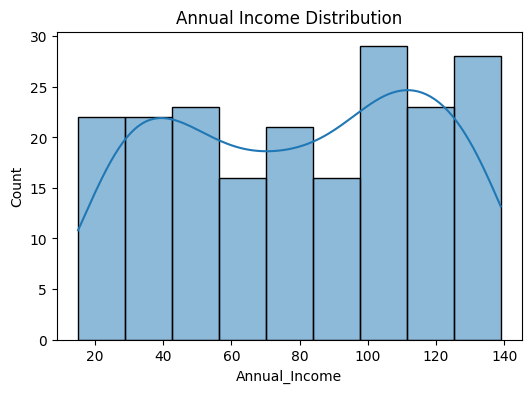

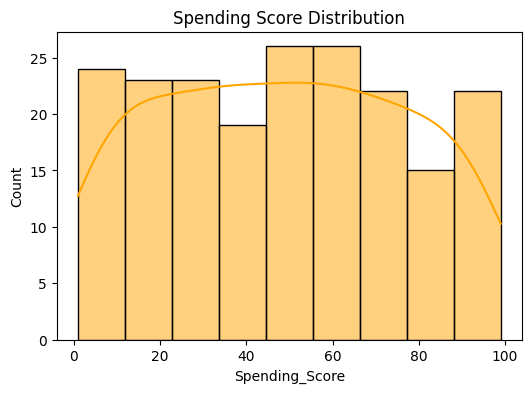

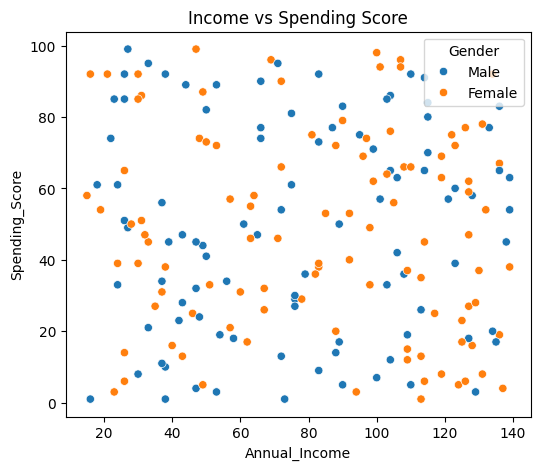

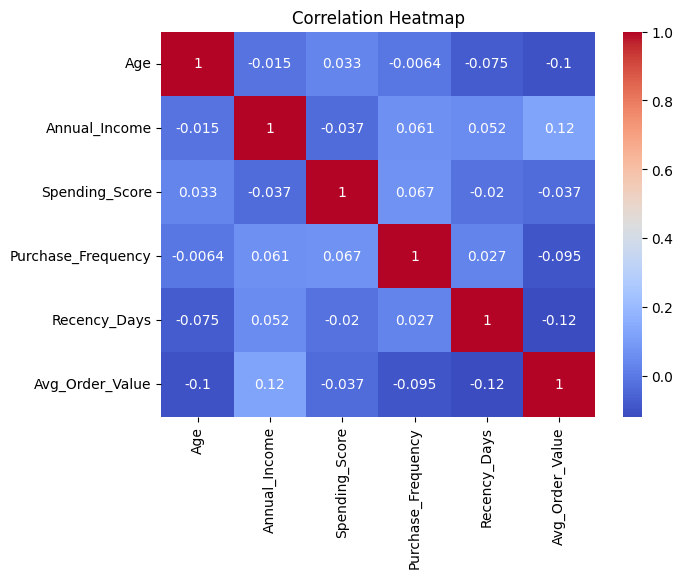

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['Annual_Income'], kde=True)
plt.title('Annual Income Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['Spending_Score'], kde=True, color='orange')
plt.title('Spending Score Distribution')
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Gender', data=df)
plt.title('Income vs Spending Score')
plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler

# Core segmentation features
features = df[['Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Recency_Days']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(scaled_features[:5])  # preview first 5 scaled rows

[[ 0.55079039 -1.45415575  0.64801871 -1.28145514]
 [-0.23219595 -0.08247661  0.92763844 -1.70251972]
 [-0.98818275 -1.24312819  0.64801871 -0.88785129]
 [ 0.33479416 -0.29350417 -0.47046019 -0.41186524]
 [ 0.71278756 -0.22316165  0.36839899  1.21747163]]


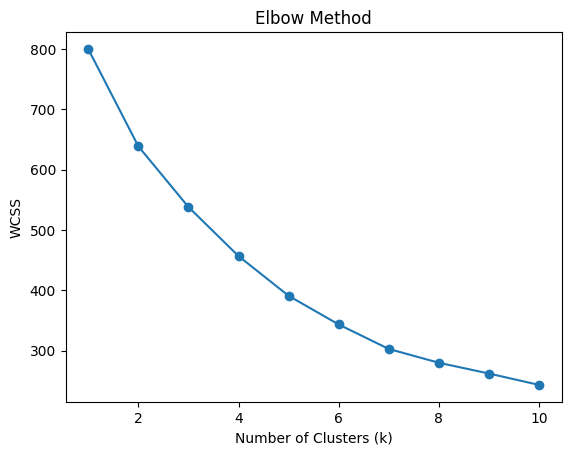

In [6]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(scaled_features)
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Purchase_Frequency,Recency_Days,Avg_Order_Value,Segment
0,CUST1000,Male,41,100,7,34,47,254.20,2
1,CUST1001,Female,69,71,46,38,1,215.27,2
2,CUST1002,Female,28,43,13,34,90,458.27,2
3,CUST1003,Female,66,92,40,18,142,187.57,2
4,CUST1004,Male,25,106,42,30,320,294.49,1


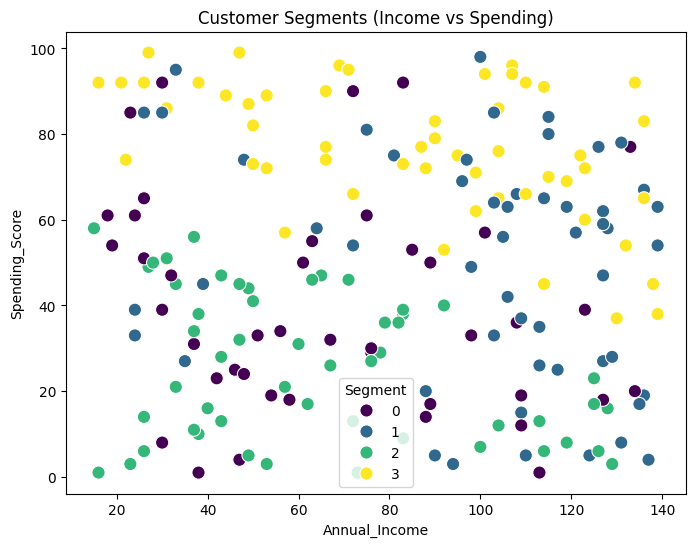

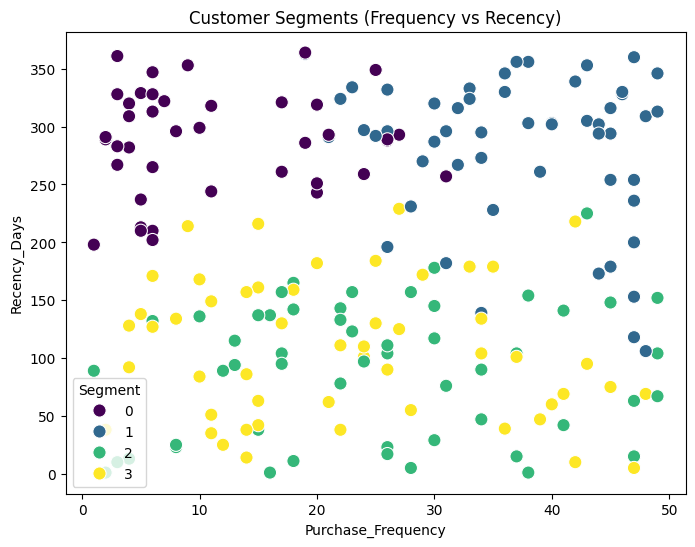

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Segment', 
                 palette='viridis', data=df, s=90)
plt.title('Customer Segments (Income vs Spending)')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Purchase_Frequency', y='Recency_Days', hue='Segment', 
                 palette='viridis', data=df, s=90)
plt.title('Customer Segments (Frequency vs Recency)')
plt.show()

In [9]:
segment_summary = df.groupby('Segment')[
    ['Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Recency_Days', 'Avg_Order_Value']
].mean().round(1)

print(segment_summary)
print(df['Segment'].value_counts())

          Age  Annual_Income  Spending_Score  Purchase_Frequency  \
Segment                                                            
0        43.4           67.0            39.5                11.4   
1        46.5          100.0            49.9                37.2   
2        46.0           63.5            26.1                25.0   
3        45.4           85.4            76.6                22.6   

         Recency_Days  Avg_Order_Value  
Segment                                 
0               288.7            213.2  
1               281.2            243.7  
2                90.1            252.8  
3               107.6            258.2  
Segment
2    53
1    53
3    52
0    42
Name: count, dtype: int64


In [10]:
df.to_csv('segmented_customers_output.csv', index=False)